Clasificación Automática de Frutas
Contexto:

Eres parte de un equipo que desarrolla una app para supermercados inteligentes. Tu tarea es crear un clasificador automático de frutas basado en dos características: peso (en gramos) y tamaño (en cm). El modelo debe aprender a distinguir entre Manzanas, Plátanos y Naranjas usando datos generados de forma simulada.



Objetivo:

Construir una solución modular en Python que:

Genere datos aleatorios simulando las características físicas de frutas.

Entrene un clasificador K-Nearest Neighbors (KNN) con esos datos.

Permita predecir el tipo de fruta dados su peso y tamaño.

Muestre gráficamente los datos con colores distintos para cada fruta.



🔧 Especificaciones técnicas

1. Crear la clase GeneradorFrutas

Método: generar(self, num_muestras)

Debe generar num_muestras pares [peso, tamaño] y su respectiva etiqueta: "Manzana", "Plátano" o "Naranja".

Rango de valores por tipo:

Manzana: peso entre 120–200g, tamaño entre 7–9cm

Plátano: peso entre 100–150g, tamaño entre 12–20cm

Naranja: peso entre 150–250g, tamaño entre 8–12cm



2. Crear la clase ClasificadorFrutas

Entrena un modelo KNN y permite hacer predicciones:

Constructor con el parámetro k (número de vecinos).

Método: entrenar(X, y) → divide en entrenamiento/test y ajusta el modelo.

Método: evaluar() → imprime y retorna la precisión del modelo sobre el set de prueba.

Método: predecir(peso, tamaño) → retorna la fruta predicha como string.



3: Crear la clase VisualizadorFrutas

Método: graficar(self, X, y, titulo="Frutas") que grafique un scatter plot (matplotlib), con color distinto por clase.



4: Clase principal SimuladorFrutas

Método: ejecutar(self)

Genera 100 muestras con GeneradorFrutas

Entrena el modelo con ClasificadorFrutas

Predice el tipo de fruta para una muestra nueva: peso 140g y tamaño 18cm

Imprime la predicción.

Muestra un gráfico de las frutas generadas.



✅ Ejemplo de uso

simulador = SimuladorFrutas()

simulador.ejecutar()


Salida esperada

🔍 Precisión del modelo: 90.00%

🍎 La fruta predicha para peso=140g y tamaño=18cm es: Plátano










Practicar con algoritmos de clasificación


# Solucion:

--- Iniciando Sistema de Clasificación de Frutas ---
🔍 Precisión del modelo: 80.00%
🍎 La fruta predicha para peso=140g y tamaño=18cm es: Plátano


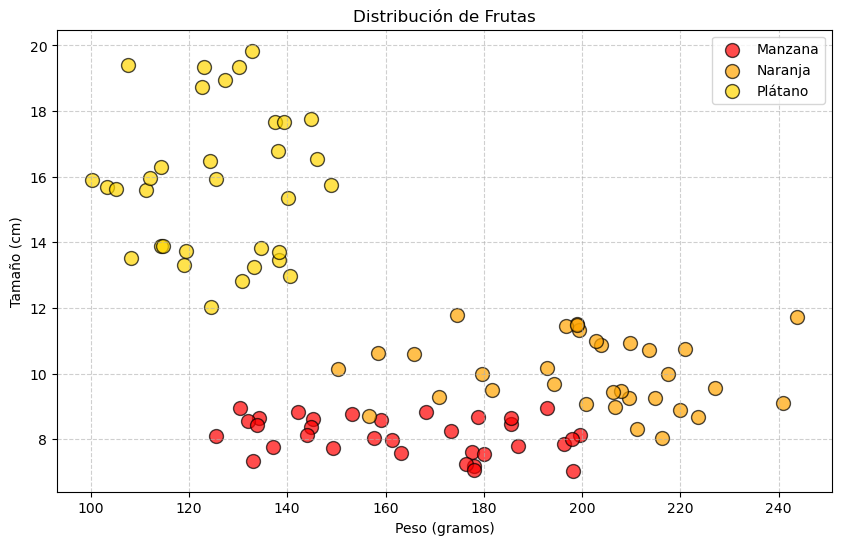

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------
# 1. Clase GeneradorFrutas
# ---------------------------------------------------------
class GeneradorFrutas:
    def generar(self, num_muestras):
        """
        Genera datos simulados de frutas.
        num_muestras: Total de muestras a generar (aprox).
        Retorna: X (features: peso, tamaño), y (labels: nombre fruta)
        """
        # Dividimos las muestras entre las 3 clases para que esté balanceado
        n_por_clase = num_muestras // 3
        
        datos_X = []
        datos_y = []
        
        # 1. Manzanas: Peso 120-200g, Tamaño 7-9cm
        for _ in range(n_por_clase):
            peso = np.random.uniform(120, 200)
            tamano = np.random.uniform(7, 9)
            datos_X.append([peso, tamano])
            datos_y.append("Manzana")
            
        # 2. Plátanos: Peso 100-150g, Tamaño 12-20cm
        for _ in range(n_por_clase):
            peso = np.random.uniform(100, 150)
            tamano = np.random.uniform(12, 20)
            datos_X.append([peso, tamano])
            datos_y.append("Plátano")
            
        # 3. Naranjas: Peso 150-250g, Tamaño 8-12cm
        for _ in range(n_por_clase):
            peso = np.random.uniform(150, 250)
            tamano = np.random.uniform(8, 12)
            datos_X.append([peso, tamano])
            datos_y.append("Naranja")
            
        return np.array(datos_X), np.array(datos_y)

# ---------------------------------------------------------
# 2. Clase ClasificadorFrutas
# ---------------------------------------------------------
class ClasificadorFrutas:
    def __init__(self, k=3):
        # K es el número de vecinos a consultar
        self.k = k
        self.modelo = KNeighborsClassifier(n_neighbors=k)
        self.X_test = None
        self.y_test = None

    def entrenar(self, X, y):
        # Dividimos en 80% entrenamiento y 20% prueba
        X_train, self.X_test, y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        self.modelo.fit(X_train, y_train)

    def evaluar(self):
        # Predecimos sobre el conjunto de test para ver qué tan bueno es
        y_pred = self.modelo.predict(self.X_test)
        precision = accuracy_score(self.y_test, y_pred)
        return precision

    def predecir(self, peso, tamano):
        # KNN espera un array 2D, así que hacemos reshape
        muestra = np.array([[peso, tamano]])
        prediccion = self.modelo.predict(muestra)
        return prediccion[0]

# ---------------------------------------------------------
# 3. Clase VisualizadorFrutas
# ---------------------------------------------------------
class VisualizadorFrutas:
    def graficar(self, X, y, titulo="Distribución de Frutas"):
        plt.figure(figsize=(10, 6))
        
        # Obtenemos las clases únicas para asignar colores (Manzana, Plátano, Naranja)
        clases = np.unique(y)
        colores = ['red', 'orange', 'gold'] # Colores aproximados a las frutas
        
        for i, clase in enumerate(clases):
            # Filtramos los puntos que pertenecen a esta clase
            puntos_clase = X[y == clase]
            plt.scatter(
                puntos_clase[:, 0], # Eje X: Peso
                puntos_clase[:, 1], # Eje Y: Tamaño
                label=clase,
                color=colores[i],
                edgecolor='k',
                s=100, alpha=0.7
            )
            
        plt.title(titulo)
        plt.xlabel("Peso (gramos)")
        plt.ylabel("Tamaño (cm)")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

# ---------------------------------------------------------
# 4. Clase SimuladorFrutas (Principal)
# ---------------------------------------------------------
class SimuladorFrutas:
    def ejecutar(self):
        print("--- Iniciando Sistema de Clasificación de Frutas ---")
        
        # 1. Generar datos
        gen = GeneradorFrutas()
        # Generamos aprox 100 muestras (serán 99 por la división entera de 3)
        X, y = gen.generar(100)
        
        # 2. Entrenar modelo
        # Usamos k=5 vecinos para decidir
        clasificador = ClasificadorFrutas(k=5)
        clasificador.entrenar(X, y)
        
        # Evaluar
        acc = clasificador.evaluar()
        print(f"🔍 Precisión del modelo: {acc*100:.2f}%")
        
        # 3. Predicción específica
        # Caso: Peso 140g, Tamaño 18cm (Debería ser Plátano por el tamaño largo)
        p_nuevo = 140
        t_nuevo = 18
        resultado = clasificador.predecir(p_nuevo, t_nuevo)
        
        print(f"🍎 La fruta predicha para peso={p_nuevo}g y tamaño={t_nuevo}cm es: {resultado}")
        
        # 4. Visualizar
        viz = VisualizadorFrutas()
        viz.graficar(X, y)

# ---------------------------------------------------------
# Punto de entrada
# ---------------------------------------------------------
if __name__ == "__main__":
    simulador = SimuladorFrutas()
    simulador.ejecutar()

Casos de prueba

Suspenso: 0, Aprobado: 3 de 3 pruebas

test_entrenamiento_y_prediccion

test_formato_salida

test_generador_num_muestras